In [5]:
import os
os.chdir("/mnt/data/users/ivan.rodkin/lab/associative-recurrent-memory-transformer")

from baselines.rwkv.language_modeling import RWKV_v6
import torch

model = RWKV_v6.from_pretrained("./RWKV-x060-World-1B6-v2.1-20240328-ctx4096.pth").to("cuda:0")

*** Setting default RWKV_MY_TESTING = x060 ***
[2025-07-27 14:47:39,818] [INFO] [real_accelerator.py:254:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/ivan.rodkin/miniconda3/envs/fla/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/ivan.rodkin/miniconda3/envs/fla/compiler_compat/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


[2025-07-27 14:47:40,628] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


Current Python version 3.10 is below the recommended 3.11 version. It is recommended to upgrade to Python 3.11 or higher for the best experience.


[RWKV.model] Running RWKV infctx using 'torch-jit' with torch '2.7.1+cu126'
[RWKV.model] Running RWKV infctx using 'torch-jit' with torch '2.7.1+cu126'


torch.compile is not available in Python 3.10, using identity decorator instead


In [8]:
inputs=dict(
    input_ids=torch.randint(0, 10000, (1, 16384 * 2)).to("cuda:0"),   
    attention_mask=torch.ones(1, 16384 * 2).to("cuda:0"),
    pad_token_id=-100,
    state=None,
    max_new_tokens=1,
    max_length=100000
)

In [9]:
output = model.generate(**inputs,)


In [9]:
import torch
from time import time

def get_time(model, seq_len):
    model.eval()
    model.to("cuda:0")
    inputs=dict(
        input_ids=torch.randint(0, 10000, (1, seq_len)).to("cuda:0"),   
        attention_mask=torch.ones(1, seq_len).to("cuda:0"),
        pad_token_id=-100,
        state=None,
        max_new_tokens=1,
        max_length=100000
    )
    start_time = time()
    model.generate(**inputs)
    end_time = time()   
    return end_time - start_time

In [13]:
import matplotlib.pyplot as plt


times = []
seq_lens = [4096, 8192, 16384, 32768, 65536]
for seq_len in seq_lens:
    cur_time = get_time(model, seq_len)
    times.append(cur_time)


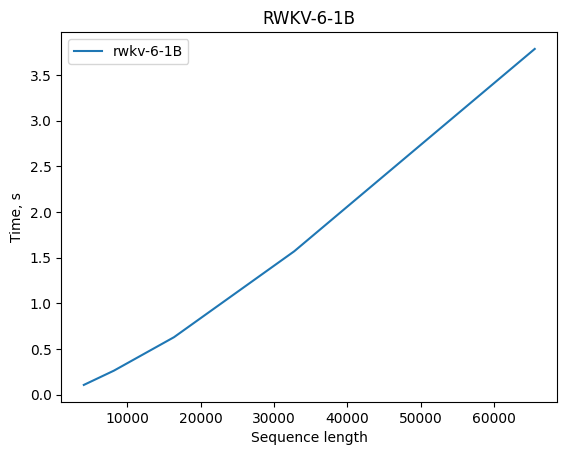

In [18]:

plt.plot(seq_lens, times, label='rwkv-6-1B')
plt.xlabel('Sequence length')
plt.ylabel('Time, s')
plt.title('RWKV-6-1B')
plt.legend()
plt.show()